# Notebook 02 — Data Preparation
## Preprocessing Pipeline: Normalization, Splitting, Tokenization

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed Adel Ebrahim Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University

---

### Objective

Transform the raw Arabic ITSM dataset into model-ready inputs:

1. **Arabic text normalization** — diacritics removal, alef normalization, latin lowercasing
2. **Stratified train/val/test split** — 70%/15%/15% stratified on L1 category
3. **Label encoding** — integer encoding for each classification task
4. **MarBERT tokenization** — WordPiece tokenization, padding/truncation at 128 tokens
5. **Length analysis post-tokenization** — verify 128-token budget is sufficient

> **Design note**: MarBERTv2 was pretrained on raw Twitter text. Aggressive normalization
> (e.g., removing all punctuation) may degrade performance. We apply only the steps
> that demonstrably improve accuracy on colloquial Egyptian text: diacritics removal
> and alef normalization.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer
from arabic_itsm.data.preprocessing import ArabicTextNormalizer

sns.set_theme(style='whitegrid')

# ── Dataset — loaded directly from GitHub, no local clone needed ───────────────
DATA_CSV = 'https://raw.githubusercontent.com/bazokhan/arabic-itsm-dataset/master/dataset_clean.csv'

OUT_DIR  = Path('../data/processed')
FIG_DIR  = Path('../results/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'UBC-NLP/MARBERTv2'
MAX_LENGTH = 128
SEED = 42

print(f'Dataset: {DATA_CSV}')
print('Setup complete')

Dataset: https://raw.githubusercontent.com/bazokhan/arabic-itsm-dataset/master/dataset_clean.csv
Setup complete


## 1. Arabic Text Normalization

In [2]:
normalizer = ArabicTextNormalizer(
    remove_diacritics=True,
    normalize_alef=True,
    normalize_teh_marbuta=False,   # Keep ة — helps dialect models distinguish gender
    lowercase_latin=True,
)

# Demonstrate normalization on sample tickets
samples = [
    'يَا جَمَاعَة السِّيسْتِم واقِع',
    'الـ VPN بيفصل كل شوية وبيظهر Timeout',
    'أنا مش قادر أدخل على الأوتلوك من الـ Office 365',
]

print('=== Normalization Examples ===')
for s in samples:
    print(f'Before: {s}')
    print(f'After : {normalizer(s)}')
    print()

=== Normalization Examples ===
Before: يَا جَمَاعَة السِّيسْتِم واقِع
After : يا جماعة السيستم واقع

Before: الـ VPN بيفصل كل شوية وبيظهر Timeout
After : الـ vpn بيفصل كل شوية وبيظهر timeout

Before: أنا مش قادر أدخل على الأوتلوك من الـ Office 365
After : انا مش قادر ادخل على الاوتلوك من الـ office 365



## 2. Load Data & Apply Normalization

In [3]:
df = pd.read_csv(DATA_CSV)
print(f'Loaded {len(df)} tickets')

# Normalize text fields
df['title_norm'] = df['title_ar'].fillna('').apply(normalizer)
df['desc_norm'] = df['description_ar'].fillna('').apply(normalizer)

# Concatenate title + description as model input
# MarBERT handles [SEP] between segments natively via segment embeddings,
# but for simplicity we concatenate with a space and pass as single sequence.
df['text'] = (df['title_norm'] + ' ' + df['desc_norm']).str.strip()

print(f'Example combined text:\n{df["text"].iloc[0][:200]}')

Loaded 10000 tickets
Example combined text:
السيستم واقع يا جماعة السيستم كله مش شغال عند كل الناس في القسم، في عطل عام؟. بقالها 21 ساعة تقريبا. لو محتاجين لوجز او سكرينشوت انا جاهز ابعتها.


## 3. Stratified Train / Val / Test Split

In [4]:
# 70 / 15 / 15 split, stratified on L1 category
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['category_level_1'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['category_level_1'], random_state=SEED
)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name}: {len(split)} samples')

# Verify stratification
print('\nL1 distribution across splits:')
dist = pd.DataFrame({
    'Train': train_df['category_level_1'].value_counts(normalize=True),
    'Val':   val_df['category_level_1'].value_counts(normalize=True),
    'Test':  test_df['category_level_1'].value_counts(normalize=True),
}).round(3)
print(dist)

Train: 7000 samples
Val: 1500 samples
Test: 1500 samples

L1 distribution across splits:
                  Train    Val   Test
category_level_1                     
Access            0.199  0.199  0.199
Hardware          0.187  0.187  0.187
Software          0.185  0.185  0.185
Network           0.182  0.182  0.182
Service           0.128  0.127  0.127
Security          0.120  0.121  0.120


## 4. Label Encoding

In [5]:
label_encoders = {}

# Fit on FULL dataset (not just train) to ensure all classes are known
for task, col in [
    ('l1', 'category_level_1'),
    ('l2', 'category_level_2'),
    ('l3', 'category_level_3'),
    ('priority', 'priority'),
    ('sentiment', 'sentiment'),
]:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    label_encoders[task] = le
    print(f'{task:10s} → {len(le.classes_)} classes: {list(le.classes_)}')

# Save encoders
with open(OUT_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print('\nLabel encoders saved to data/processed/label_encoders.pkl')

l1         → 6 classes: ['Access', 'Hardware', 'Network', 'Security', 'Service', 'Software']
l2         → 16 classes: ['Account', 'Business App', 'Email/Calendar', 'Incident', 'Internet/LAN', 'Laptop/Desktop', 'MFA/SSO', 'Malware/Phishing', 'Office Apps', 'Peripherals', 'Permissions', 'Policy/Compliance', 'Printer/Scanner', 'Request', 'VPN', 'WiFi']
l3         → 48 classes: ['Account Locked', 'Admin Access', 'Authentication', 'Authenticator Issue', 'Battery', 'Blocked Site', 'Boot Issue', 'Bug', 'Connection Failure', 'Connectivity', 'Crash', 'Credentials', 'DNS', 'Data Access', 'Degradation', 'Device Encryption', 'Docking Station', 'Driver', 'Feature Request', 'Integration', 'Intermittent', 'Keyboard/Mouse', 'Latency', 'License', 'MFA Failure', 'Mailbox Access', 'Monitor', 'New Account', 'New Device', 'No Internet', 'Outage', 'Outlook Issue', 'Paper Jam', 'Password Reset', 'Performance', 'Permission Denied', 'Phishing Email', 'Print Failure', 'Profile Update', 'Role Request', 'SSO Logi

## 5. MarBERT Tokenization Analysis

We verify that our `max_length=128` budget covers the vast majority of tickets
after tokenization with MarBERT's WordPiece vocabulary.

In [7]:
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,}')

Loading tokenizer: UBC-NLP/MARBERTv2
Vocab size: 100,000


In [8]:
# Token length distribution on the full dataset
print('Computing token lengths (this may take a moment)...')

token_lengths = df['text'].apply(
    lambda t: len(tokenizer.encode(t, add_special_tokens=True))
)

print(token_lengths.describe().round(1))
coverage_128 = (token_lengths <= MAX_LENGTH).mean() * 100
print(f'\nTickets fitting within {MAX_LENGTH} tokens: {coverage_128:.1f}%')

Computing token lengths (this may take a moment)...
count    10000.0
mean        44.5
std         13.3
min         23.0
25%         34.0
50%         40.0
75%         56.0
max        107.0
Name: text, dtype: float64

Tickets fitting within 128 tokens: 100.0%


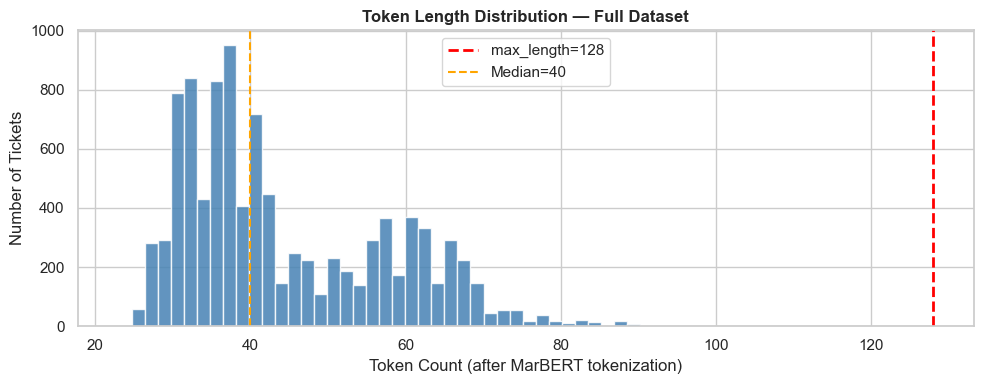

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(MAX_LENGTH, color='red', linestyle='--', linewidth=2, label=f'max_length={MAX_LENGTH}')
plt.axvline(token_lengths.median(), color='orange', linestyle='--', label=f'Median={token_lengths.median():.0f}')
plt.xlabel('Token Count (after MarBERT tokenization)')
plt.ylabel('Number of Tickets')
plt.title('Token Length Distribution — Full Dataset', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '02_token_lengths.png', bbox_inches='tight')
plt.show()

## 6. Save Processed Splits

In [10]:
# Add encoded labels to each split
for split_df in [train_df, val_df, test_df]:
    for task, col in [('l1', 'category_level_1'), ('l2', 'category_level_2'),
                      ('priority', 'priority'), ('sentiment', 'sentiment')]:
        split_df[f'label_{task}'] = label_encoders[task].transform(
            split_df[col].astype(str)
        )

cols_to_save = ['ticket_id', 'text', 'title_ar', 'description_ar',
                'category_level_1', 'category_level_2', 'category_level_3',
                'label_l1', 'label_l2', 'priority', 'label_priority',
                'sentiment', 'label_sentiment']

train_df[cols_to_save].to_csv(OUT_DIR / 'train.csv', index=False)
val_df[cols_to_save].to_csv(OUT_DIR / 'val.csv', index=False)
test_df[cols_to_save].to_csv(OUT_DIR / 'test.csv', index=False)

print('Splits saved:')
for name, path in [('Train', OUT_DIR / 'train.csv'),
                   ('Val',   OUT_DIR / 'val.csv'),
                   ('Test',  OUT_DIR / 'test.csv')]:
    print(f'  {name}: {path}  ({path.stat().st_size / 1024:.0f} KB)')

Splits saved:
  Train: ..\data\processed\train.csv  (4500 KB)
  Val: ..\data\processed\val.csv  (960 KB)
  Test: ..\data\processed\test.csv  (964 KB)


## 7. Summary

| Step | Result |
|------|--------|
| Normalization | Diacritics removed, alef normalized, Latin lowercased |
| Text input | `title_norm + " " + desc_norm` (single sequence) |
| Split | 70/15/15 stratified on L1 |
| Label encoders | Fit on full dataset; 5 tasks encoded |
| Token coverage @ 128 | See above |

**Next**: Notebook 03 — Baseline Models (TF-IDF + classical ML)